<img src="../img/images.jpg" height="200" width="370"/>  <img src="../img/grad_cam.jpg" height="200" width="370"/> 
# 🩺 Détection de Pneumonie sur Radiographies Thoraciques utilisant le Transfer/Ensemble Learning (à partir de modèles pré-entraînés de type CNN)

# Contexte du projet


Une équipe médicale souhaite tester l’apport de l’intelligence artificielle dans **le diagnostic automatisé de la pneumonie à partir de radios thoraciques.** Elle a besoin d’un prototype fonctionnel (Proof of Concept) permettant de démontrer la faisabilité d’**un système de classification binaire d’images médicales**.

>Le problème posé consiste à réutiliser un modèle de vision par ordinateur **pré-entraîné (type CNN)** pour l’adapter au contexte médical, sans repartir d’un entraînement complet.

> Dans une logique de mise en production à moyen terme, il est également attendu de documenter et tracer les expérimentations réalisées. L’usage de **MLflow** est proposé pour initier cette démarche, en assurant le suivi des performances, la traçabilité des essais et la gestion des versions de modèles dans une perspective MLOps.

# Modalités d'évaluation
Évaluation individuelle à partir du livrable (notebook). 
Le barème porte sur 
- **la qualité de la démarche (pertinence des choix, rigueur des étapes, clarté des explications),** 
- **la bonne compréhension du transfert learning,**
- **et l’initiation à MLflow (usage basique)**.

# Livrables
Un **lien GitHub** contenant les travaux réalisés, notamment un notebook complet, structuré, lisible et commenté, incluant :
- Préparation et exploration du dataset
- Mise en place du modèle pré-entraîné et adaptation
- Entraînement, évaluation (matrice de confusion, courbes, métriques etc...)
- Suivi des expériences via MLflow
- Le dépôt du code sur GitHub avec les travaux réalisé (notebook) avec un README synthétique

# Critères de performance
- Le notebook couvre toutes **les étapes clés de la démarche** (pré-traitement, modélisation, évaluation)
- Les **choix techniques sont justifiés** avec clarté et cohérence
- Le **modèle est adapté** de manière correcte à la tâche de classification binaire
- L’**évaluation du modèle est rigoureuse** (métriques pertinentes, commentaires clairs)
- La première utilisation de **MLflow est fonctionnelle et comprise** (log simple de paramètres ou de métriques)
- Le **code est structuré, commenté, exécutable**
- *La performance du modèle n'est pas un critère de performances, seul compte la démarche, la compréhension et donc la clarté des notes dans le le notebook*

----

# 1. Chargement des bibliothèques nécessaires

 - Création manuelle d'un environnment virtuel `python -m venv .venv` et l'activer ` .\.venv\Scripts\Activate.ps1` (sous windows os)
 - Installer les bibliothèques `pip install -r requirements.txt` 
 - choisir le dossier .venv dans "Python: Select interpreter" (Command Palette)
 (venv contenant python 3.10 compatible avec tensorflow)
 - installer ipykernel pour executer

In [1]:
import os  # os pour manipuler des dossiers et fichiers
import numpy as np # np pour manipuler des vecteurs et matrices
import pandas as pd # pd pour traiter des dataframe et visualiser des figures
import seaborn as sns # pd pour visualiser des figures

import mlflow #  pour documenter et tracer les expérimentations réalisées.
import mlflow.tensorflow
# DL Lib
import tensorflow as tf 

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121, ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt  #  pour visualiser des figures
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import roc_curve,roc_auc_score,auc, confusion_matrix, classification_report,accuracy_score # pd pour évaluer le modèle
import cv2


# 2. Préparation et exploration du dataset

[[[ 24  24  24]
  [ 20  20  20]
  [ 19  19  19]
  ...
  [ 95  95  95]
  [ 94  94  94]
  [ 95  95  95]]

 [[ 22  22  22]
  [ 22  22  22]
  [ 17  17  17]
  ...
  [ 91  91  91]
  [ 95  95  95]
  [ 95  95  95]]

 [[ 24  24  24]
  [ 21  21  21]
  [ 20  20  20]
  ...
  [ 93  93  93]
  [ 93  93  93]
  [ 92  92  92]]

 ...

 [[ 29  29  29]
  [ 29  29  29]
  [ 29  29  29]
  ...
  [ 61  61  61]
  [ 59  59  59]
  [ 59  59  59]]

 [[ 34  34  34]
  [ 33  33  33]
  [ 35  35  35]
  ...
  [ 79  79  79]
  [ 81  81  81]
  [ 82  82  82]]

 [[ 46  46  46]
  [ 45  45  45]
  [ 45  45  45]
  ...
  [108 108 108]
  [113 113 113]
  [110 110 110]]]


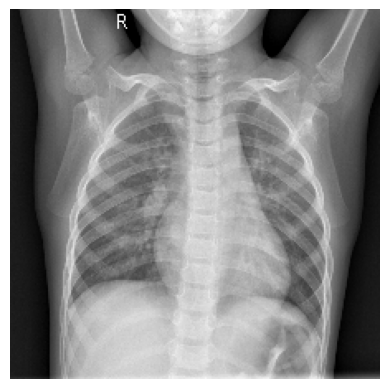

Shape (dimensions)    : (224, 224, 3)
Type des valeurs      : uint8


In [2]:
# On charge une image depuis le répertoire data/
img = cv2.imread("../data/train/NORMAL/IM-0115-0001.jpeg", cv2.IMREAD_GRAYSCALE)
# Convert to 3 channels
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # Now shape is (H, W, 3)
# Resize to model input size (e.g., 224x224)
resized_img = cv2.resize(img_rgb, (224, 224))
# Observer l'image sous forme de matrice
print(resized_img)

# Visualisation de l'image
plt.imshow(resized_img, cmap="gray")
plt.axis("off")
plt.show()

# Inspection des métadonnées de l'image
print(f"Shape (dimensions)    : {resized_img.shape}")
print(f"Type des valeurs      : {resized_img.dtype}")

## Chargement des données

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Create ImageDataGenerator instances & normalization
train_datagen = ImageDataGenerator(rescale=1./255)  
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    '../data/train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'  # Converts grayscale to 3 channels automatically
)

val_generator = val_datagen.flow_from_directory(
    '../data/val',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    '../data/test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False  # Usually better for evaluation
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Vérification

In [4]:
import sys
import os

# Go one directory up from notebooks to find utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.functions_data import generator_to_numpy
# Convert generators to NumPy arrays
X_train, y_train = generator_to_numpy(train_generator)
X_val, y_val = generator_to_numpy(val_generator)
X_test, y_test = generator_to_numpy(test_generator)


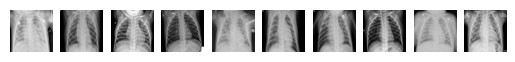

In [5]:
# Vérification des données préparées
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap="grey")
   
    plt.axis("off")

plt.show()

# 3. Modélisation & compilation

- Pour un transfer learning : choisir selon les performances le modèle de base pré-entrainé (VGG16, DenseNet121 ...) sur les données ImageNet
- Pour un ensemble learning : combiner plusieurs modèles ensemble

In [6]:
def build_model(base_model_class):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # freeze base

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.5)(x)
    x = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=x)
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_densenet = build_model(DenseNet121)
model_resnet = build_model(ResNet50V2)


---

# 4. Mlflow tracking 

In [7]:
mlflow.tensorflow.autolog()
mlflow.set_experiment("Ensemble-avg")

2025/05/28 18:34:19 INFO mlflow.tracking.fluent: Experiment with name 'Ensemble-avg' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/User/Desktop/DL_transfer_CNN_pneumonia/notebooks/mlruns/750534007345104798', creation_time=1748450059926, experiment_id='750534007345104798', last_update_time=1748450059926, lifecycle_stage='active', name='Ensemble-avg', tags={}>

## Fitting

In [ ]:
with mlflow.start_run(run_name="run-ensemble"):
    model_densenet.fit(train_generator, validation_data=val_generator, epochs=5)
    model_resnet.fit(train_generator, validation_data=val_generator, epochs=5)

     # log the model
    mlflow.keras.log_model(model_densenet,"model_densenet")
    mlflow.keras.log_model(model_resnet,"model_resnet")
    

2025/05/28 18:34:34 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/05/28 18:34:34 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
c:\Users\User\Desktop\DL_transfer_CNN_pneumonia\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5956 - loss: 0.7807

163/163 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step - accuracy: 0.5958 - loss: 0.7804 - val_accuracy: 0.5000 - val_loss: 0.7301
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6916 - loss: 0.6550

163/163 ━━━━━━━━━━━━━━━━━━━━ 571s 3s/step - accuracy: 0.6916 - loss: 0.6549 - val_accuracy: 0.5000 - val_loss: 0.6501
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7330 - loss: 0.5400

163/163 ━━━━━━━━━━━━━━━━━━━━ 508s 3s/step - accuracy: 0.7331 - loss: 0.5400 - val_accuracy: 0.5000 - val_loss: 0.6053
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7706 - loss: 0.4883

...

2025/05/28 19:17:52 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2025/05/28 19:17:52 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/28 19:18:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/05/28 19:18:42 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/05/28 19:18:42 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.7184 - loss: 0.5912 

163/163 ━━━━━━━━━━━━━━━━━━━━ 4903s 30s/step - accuracy: 0.7186 - loss: 0.5908 - val_accuracy: 0.5000 - val_loss: 0.8139
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8287 - loss: 0.3771

163/163 ━━━━━━━━━━━━━━━━━━━━ 506s 3s/step - accuracy: 0.8288 - loss: 0.3769 - val_accuracy: 0.5625 - val_loss: 0.6664
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8787 - loss: 0.2827

163/163 ━━━━━━━━━━━━━━━━━━━━ 483s 3s/step - accuracy: 0.8787 - loss: 0.2827 - val_accuracy: 0.7500 - val_loss: 0.5450
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 460s 3s/step - accuracy: 0.9057 - loss: 0.2416 - val_accuracy: 0.6875 - val_loss: 0.5577
Epoch 5/5
157/163 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9053 - loss: 0.2265

In [16]:
# Predict on test data
vgg_preds = model_densenet.predict(test_generator)
resnet_preds = model_resnet.predict(test_generator)

# Average predictions
ensemble_preds = (vgg_preds + resnet_preds) / 2
ensemble_preds_binary = (ensemble_preds > 0.5).astype(int)

y_true = test_generator.classes
print("\nClassification Report:")
print(classification_report(y_true, ensemble_preds_binary))

# Compute ensemble accuracy
ensemble_accuracy = accuracy_score(y_true, ensemble_preds_binary)
print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")

print("Confusion Matrix:")
print(confusion_matrix(y_true, ensemble_preds_binary))


KeyboardInterrupt: 

In [15]:
ensemble_accuracy = accuracy_score(y_true, ensemble_preds_binary)
ensemble_accuracy

0.7548076923076923

---